In [1]:
# CELL 1
!pip install transformers

In [2]:
# CELL 2
import os
import pandas as pd
import matplotlib.pyplot as plt
import cv2
from sklearn.model_selection import train_test_split
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import models, transforms
import time
from transformers import CLIPModel, CLIPProcessor, ViTModel, ViTFeatureExtractor
import numpy as np
import torch.optim as optim
from sklearn.metrics import f1_score, precision_score, recall_score
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
from PIL import Image
from torch.utils.tensorboard import SummaryWriter
from torch.optim.lr_scheduler import StepLR


In [ ]:
# CELL 3
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Train Metadata Loaded: (33126, 9)
Test Metadata Loaded: (10982, 5)

Filtered Metadata Size After Validation: 33126

Filtered Test Metadata Size After Validation: 10982

Filtered Train Metadata Size After Removing Classes with Fewer Than 2 Samples: 33124

Updated Train Label Mapping: {'unknown': 0, 'nevus': 1, 'melanoma': 2, 'seborrheic keratosis': 3, 'lentigo NOS': 4, 'lichenoid keratosis': 5, 'solar lentigo': 6}

Visualizing some training samples...


<ipython-input-6-098af18fc4e8>:53: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  train_filtered_metadata['label'] = train_filtered_metadata['diagnosis'].map(train_label_mapping)


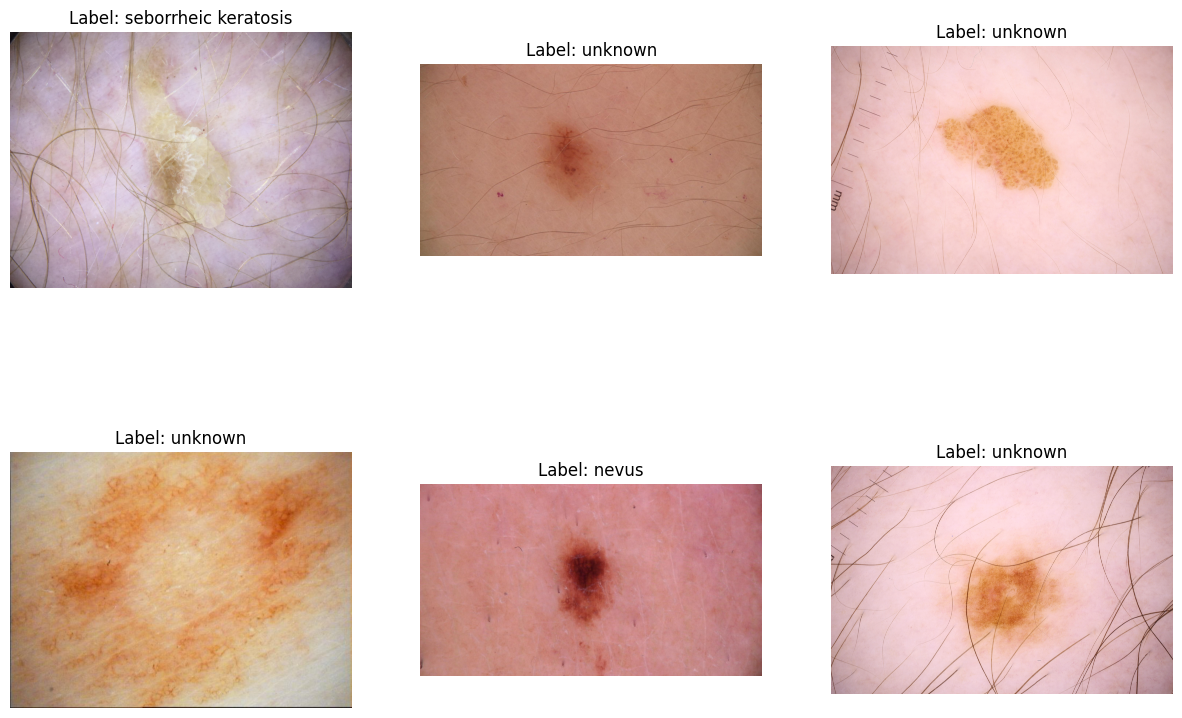


Training Set Size: 26499
Validation Set Size: 6625

Data loaders created successfully.


/usr/local/lib/python3.11/dist-packages/torch/utils/data/dataloader.py:624: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(



Sample Batch Shape (Images): torch.Size([32, 3, 224, 224])
Sample Batch Shape (Labels): torch.Size([32])


In [ ]:
# DATASET
# Paths for Colab
DATASET_PATH = "/content/drive/MyDrive/THESIS/Dataset/kaggle"
TRAIN_IMAGES_PATH = os.path.join(DATASET_PATH, "train")
TEST_IMAGES_PATH = os.path.join(DATASET_PATH, "test")
TRAIN_METADATA_PATH = os.path.join(DATASET_PATH, "ISIC_2020_Train_Metadata.csv")
TEST_METADATA_PATH = os.path.join(DATASET_PATH, "ISIC_2020_Test_Metadata.csv")

# Verify if the dataset paths exist
assert os.path.exists(TRAIN_IMAGES_PATH), f"Train images path does not exist: {TRAIN_IMAGES_PATH}"
assert os.path.exists(TEST_IMAGES_PATH), f"Test images path does not exist: {TEST_IMAGES_PATH}"
assert os.path.exists(TRAIN_METADATA_PATH), f"Train metadata file does not exist: {TRAIN_METADATA_PATH}"
assert os.path.exists(TEST_METADATA_PATH), f"Test metadata file does not exist: {TEST_METADATA_PATH}"

# Load metadata
train_metadata = pd.read_csv(TRAIN_METADATA_PATH)
test_metadata = pd.read_csv(TEST_METADATA_PATH)

print("Train Metadata Loaded:", train_metadata.shape)
print("Test Metadata Loaded:", test_metadata.shape)

# Add file extension to image names in metadata
train_metadata['image_name_with_ext'] = train_metadata['image_name'] + '.jpg'

# List all image files in the train folder
train_image_files = set(os.listdir(TRAIN_IMAGES_PATH))

# Filter metadata for images that exist in the train folder
filtered_train_metadata = train_metadata[train_metadata['image_name_with_ext'].isin(train_image_files)]

print("\nFiltered Metadata Size After Validation:", len(filtered_train_metadata))

# Add .jpg extension to test image names
test_metadata['image_name_with_ext'] = test_metadata['image'] + '.jpg'

# List all image files in the test folder
test_image_files = set(os.listdir(TEST_IMAGES_PATH))

# Filter metadata for existing test images
filtered_test_metadata = test_metadata[test_metadata['image_name_with_ext'].isin(test_image_files)]

print("\nFiltered Test Metadata Size After Validation:", len(filtered_test_metadata))

# Handle edge cases for labels with fewer than 2 samples
train_class_counts = filtered_train_metadata['diagnosis'].value_counts()
train_valid_classes = train_class_counts[train_class_counts > 1].index
train_filtered_metadata = filtered_train_metadata[filtered_train_metadata['diagnosis'].isin(train_valid_classes)]

print("\nFiltered Train Metadata Size After Removing Classes with Fewer Than 2 Samples:", len(train_filtered_metadata))

# Encode labels
train_label_mapping = {label: idx for idx, label in enumerate(train_filtered_metadata['diagnosis'].unique())}
train_filtered_metadata['label'] = train_filtered_metadata['diagnosis'].map(train_label_mapping)

print("\nUpdated Train Label Mapping:", train_label_mapping)

# Visualize sample images
def visualize_samples(image_dir, metadata, num_samples=6):
    if metadata.empty:
        print("\nNo valid samples to visualize. Metadata is empty.")
        return

    sample_images = metadata.sample(num_samples)
    plt.figure(figsize=(15, 10))
    for idx, (_, row) in enumerate(sample_images.iterrows()):
        img_path = os.path.join(image_dir, row['image_name_with_ext'])
        image = cv2.imread(img_path)
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        plt.subplot(2, 3, idx + 1)
        plt.imshow(image)
        plt.title(f"Label: {row['diagnosis']}")
        plt.axis("off")
    plt.show()

print("\nVisualizing some training samples...")
visualize_samples(TRAIN_IMAGES_PATH, train_filtered_metadata)

# Split train and validation sets
if not train_filtered_metadata.empty:
    train_df, val_df = train_test_split(
        train_filtered_metadata, test_size=0.2, stratify=train_filtered_metadata['label'], random_state=42
    )

    print("\nTraining Set Size:", len(train_df))
    print("Validation Set Size:", len(val_df))
else:
    print("\nNo data to split for training and validation.")

# Define dataset class
class ISICDataset(Dataset):
    def __init__(self, metadata, image_dir, transform=None):
        self.metadata = metadata
        self.image_dir = image_dir
        self.transform = transform

    def __len__(self):
        return len(self.metadata)

    def __getitem__(self, idx):
        row = self.metadata.iloc[idx]
        img_path = os.path.join(self.image_dir, row['image_name_with_ext'])
        image = cv2.imread(img_path)
        if image is None:
            raise FileNotFoundError(f"Image not found at {img_path}")
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        label = row['label']
        if self.transform:
            image = self.transform(image)
        return image, label

# Data transformations
data_transforms = transforms.Compose([
    transforms.ToPILImage(),
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

# Create datasets and data loaders
if not train_filtered_metadata.empty:
    train_dataset = ISICDataset(train_df, TRAIN_IMAGES_PATH, transform=data_transforms)
    val_dataset = ISICDataset(val_df, TRAIN_IMAGES_PATH, transform=data_transforms)

    train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=4)
    val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False, num_workers=4)

    print("\nData loaders created successfully.")

    # Test the data loader
    images, labels = next(iter(train_loader))
    print("\nSample Batch Shape (Images):", images.size())
    print("Sample Batch Shape (Labels):", labels.size())
else:
    print("\nNo valid data loaders created due to empty metadata.")

In [ ]:
# MODEL

# Load the pre-trained CLIP model
clip_model = CLIPModel.from_pretrained("openai/clip-vit-base-patch32")
clip_processor = CLIPProcessor.from_pretrained("openai/clip-vit-base-patch32")

# Extract the vision encoder
vision_encoder = clip_model.vision_model

# Unfreeze the last 4-5 layers for fine-tuning
for name, param in vision_encoder.named_parameters():
    param.requires_grad = False  # Freeze all layers by default
    if "encoder.layers.10" in name or "encoder.layers.11" in name:
        param.requires_grad = True  # Unfreeze the last 2 layers
    if "final_layer_norm" in name:  # Also unfreeze the final normalization layer
        param.requires_grad = True

# Test the vision encoder output shape
dummy_input = torch.randn(1, 3, 224, 224)  # Batch size 1, RGB image of 224x224
vision_output = vision_encoder(dummy_input)

print("Vision Encoder Output Shape:", vision_output[0].shape)  # Shape: [batch_size, seq_length, hidden_dim]

# Add a custom feature extractor to adapt the vision encoder's output
class VisionFeatureExtractor(nn.Module):
    def __init__(self, vision_encoder, feature_dim=768):
        super(VisionFeatureExtractor, self).__init__()
        self.vision_encoder = vision_encoder
        self.avg_pool = nn.AdaptiveAvgPool1d(1)  # Pool across the sequence length
        self.feature_dim = feature_dim

    def forward(self, x):
        # Vision encoder output: [batch_size, seq_length, hidden_dim]
        vision_output = self.vision_encoder(x)[0]
        # Average pool across sequence dimension to reduce output: [batch_size, hidden_dim]
        pooled_output = self.avg_pool(vision_output.permute(0, 2, 1)).squeeze(-1)
        return pooled_output

# Instantiate the feature extractor
feature_extractor = VisionFeatureExtractor(vision_encoder)

# Test the feature extractor
extracted_features = feature_extractor(dummy_input)
print("Extracted Features Shape:", extracted_features.shape)  # Shape: [batch_size, hidden_dim]

In [ ]:
import torch.nn as nn
import torch

# Define the CBAM Block
class CBAM(nn.Module):
    def __init__(self, channels, reduction_ratio=16, kernel_size=7):
        super(CBAM, self).__init__()
        # Channel Attention Module
        self.channel_attention = nn.Sequential(
            nn.AdaptiveAvgPool2d(1),
            nn.Conv2d(channels, channels // reduction_ratio, kernel_size=1, bias=False),
            nn.ReLU(),
            nn.Conv2d(channels // reduction_ratio, channels, kernel_size=1, bias=False),
            nn.Sigmoid(),
        )
        # Spatial Attention Module
        self.spatial_attention = nn.Sequential(
            nn.Conv2d(2, 1, kernel_size=kernel_size, padding=kernel_size // 2, bias=False),
            nn.Sigmoid(),
        )

    def forward(self, x):
        # Channel Attention
        channel_attention = self.channel_attention(x)
        x = x * channel_attention

        # Spatial Attention
        avg_out = torch.mean(x, dim=1, keepdim=True)
        max_out, _ = torch.max(x, dim=1, keepdim=True)
        spatial_attention_input = torch.cat([avg_out, max_out], dim=1)
        spatial_attention = self.spatial_attention(spatial_attention_input)
        x = x * spatial_attention

        return x


# Modify the VisionFeatureExtractor to include CBAM
class VisionFeatureExtractorWithCBAM(nn.Module):
    def __init__(self, vision_encoder, channels=768, reduction_ratio=16, kernel_size=7):
        super(VisionFeatureExtractorWithCBAM, self).__init__()
        self.vision_encoder = vision_encoder
        self.cbam = CBAM(channels, reduction_ratio, kernel_size)
        self.avg_pool = nn.AdaptiveAvgPool2d((1, 1))  # Pool across spatial dimensions

    def forward(self, x):
        # Pass through the vision encoder
        vision_output = self.vision_encoder(x)[0]  # Output: [batch_size, seq_length, hidden_dim]
        # Remove the [CLS] token (first token) from the sequence
        vision_output = vision_output[:, 1:, :]  # [batch_size, seq_length - 1, hidden_dim]

        # Reshape to 2D feature maps for CBAM (assuming seq_length is equivalent to spatial dimensions)
        b, seq_len, hidden_dim = vision_output.shape
        h = w = int(seq_len**0.5)  # Assuming the feature map is square
        if h * w != seq_len:
            raise ValueError(
                f"Sequence length ({seq_len}) does not form a square feature map (h={h}, w={w})."
            )
        vision_output_reshaped = vision_output.permute(0, 2, 1).reshape(b, hidden_dim, h, w)  # [batch_size, channels, height, width]

        # Pass through the CBAM block
        cbam_output = self.cbam(vision_output_reshaped)

        # Pool the CBAM output to a single feature vector per image
        pooled_output = self.avg_pool(cbam_output).squeeze(-1).squeeze(-1)  # [batch_size, channels]
        return pooled_output


# Instantiate the feature extractor with CBAM
feature_extractor_with_cbam = VisionFeatureExtractorWithCBAM(vision_encoder, channels=768)

# Test the feature extractor with CBAM
dummy_input = torch.randn(1, 3, 224, 224)  # Batch size 1, RGB image of 224x224
features_with_cbam = feature_extractor_with_cbam(dummy_input)
print("Features with CBAM Shape:", features_with_cbam.shape)  # Expected shape: [batch_size, channels]

In [ ]:
import torch.nn as nn

class SkinLesionClassifier(nn.Module):
    def __init__(self, vision_encoder, num_classes, channels=768, reduction_ratio=16, kernel_size=7):
        super(SkinLesionClassifier, self).__init__()
        # Feature extractor with CBAM
        self.feature_extractor = VisionFeatureExtractorWithCBAM(
            vision_encoder, channels=channels, reduction_ratio=reduction_ratio, kernel_size=kernel_size
        )
        # Classification head
        self.classifier = nn.Sequential(
            nn.Linear(channels, 256),  # Fully connected layer (reduce dimensionality to 256)
            nn.ReLU(),                # Activation
            nn.Dropout(0.5),          # Dropout for regularization
            nn.Linear(256, num_classes),  # Map to the number of classes
            nn.Softmax(dim=1)         # Softmax for classification probabilities
        )

    def forward(self, x):
        features = self.feature_extractor(x)  # Extract features using CBAM
        logits = self.classifier(features)    # Pass through the classification head
        return logits

In [ ]:
import time

# Training configuration
num_epochs = 10  # Number of epochs to train
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")  # Check GPU availability

# Training and Validation Loops
def train_and_evaluate(model, train_loader, val_loader, criterion, optimizer, num_epochs, device):
    print("\nStarting Training...")
    model = model.to(device)

    for epoch in range(num_epochs):
        # Training phase
        model.train()  # Set the model to training mode
        running_loss = 0.0
        train_correct = 0
        train_total = 0

        start_time = time.time()

        for batch_idx, (images, labels) in enumerate(train_loader):
            images, labels = images.to(device), labels.to(device)

            # Forward pass
            outputs = model(images)
            loss = criterion(outputs, labels)

            # Backward pass and optimization
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            # Track training loss and accuracy
            running_loss += loss.item()
            _, predicted = torch.max(outputs, 1)
            train_total += labels.size(0)
            train_correct += (predicted == labels).sum().item()

            # Print batch progress
            if (batch_idx + 1) % 10 == 0 or batch_idx == len(train_loader) - 1:  # Monitor every 10 batches
                print(
                    f"Epoch [{epoch + 1}/{num_epochs}], Batch [{batch_idx + 1}/{len(train_loader)}], "
                    f"Batch Loss: {loss.item():.4f}, "
                    f"Running Accuracy: {100 * train_correct / train_total:.2f}%"
                )

        epoch_loss = running_loss / len(train_loader)
        epoch_accuracy = 100 * train_correct / train_total
        end_time = time.time()

        print(
            f"\nEpoch [{epoch + 1}/{num_epochs}], "
            f"Training Loss: {epoch_loss:.4f}, "
            f"Training Accuracy: {epoch_accuracy:.2f}%, "
            f"Time: {end_time - start_time:.2f}s"
        )

        # Validation phase
        model.eval()  # Set the model to evaluation mode
        val_loss = 0.0
        val_correct = 0
        val_total = 0

        with torch.no_grad():  # Disable gradient calculation for validation
            for batch_idx, (images, labels) in enumerate(val_loader):
                images, labels = images.to(device), labels.to(device)

                outputs = model(images)
                loss = criterion(outputs, labels)
                val_loss += loss.item()

                _, predicted = torch.max(outputs, 1)
                val_total += labels.size(0)
                val_correct += (predicted == labels).sum().item()

                # Print batch progress
                if (batch_idx + 1) % 10 == 0 or batch_idx == len(val_loader) - 1:  # Monitor every 10 batches
                    print(
                        f"Validation Batch [{batch_idx + 1}/{len(val_loader)}], "
                        f"Running Validation Accuracy: {100 * val_correct / val_total:.2f}%"
                    )

        val_epoch_loss = val_loss / len(val_loader)
        val_epoch_accuracy = 100 * val_correct / val_total

        print(
            f"Validation Loss: {val_epoch_loss:.4f}, "
            f"Validation Accuracy: {val_epoch_accuracy:.2f}%\n"
        )

    print("Training Complete!")

# Assuming the VisionFeatureExtractorWithCBAM and all necessary imports are already defined above

# Define the number of classes (based on your dataset)
num_classes = len(train_label_mapping)  # Replace `label_mapping` with the actual mapping of classes in your dataset

# Instantiate the SkinLesionClassifier model
# vision_encoder = clip_model.visual  # Replace this with your actual vision encoder model (e.g., CLIP vision encoder)
skin_lesion_classifier = SkinLesionClassifier(
    vision_encoder=vision_encoder,
    num_classes=num_classes,
    channels=768,  # Adjust based on your vision encoder output dimension
    reduction_ratio=16,
    kernel_size=7
)

# Define the loss function and optimizer
criterion = nn.CrossEntropyLoss()  # Use CrossEntropyLoss for classification tasks
optimizer = torch.optim.Adam(skin_lesion_classifier.parameters(), lr=1e-4)

# Assuming `train_loader` and `val_loader` are already defined and contain the training and validation data loaders

# Training configuration
num_epochs = 10  # Number of epochs to train
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")  # Check GPU availability

# Call the function to train and evaluate
train_and_evaluate(
    model=skin_lesion_classifier,
    train_loader=train_loader,
    val_loader=val_loader,
    criterion=criterion,
    optimizer=optimizer,
    num_epochs=num_epochs,
    device=device
)
